In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
def describe_dataframe(dataframe, rounding_factor = 4, remove_zeros = False):

    import pandas as pd

    df_desc = pd.DataFrame(columns=['Column', 'Missing'])

    for col in dataframe.columns:
        missing_percentage = dataframe[col].isnull().sum() * 100 / len(dataframe[col])
    
        df_desc = df_desc.append({'Column': col, 
                                'Missing': round(missing_percentage, rounding_factor)}, ignore_index = True)
        
        if remove_zeros:
            df_desc = df_desc[df_desc["Missing"] != 0]

    return df_desc


In [3]:
df = pd.read_csv('GR_Timeline_2009-2022_filled.csv', encoding='utf-8')

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3553: DtypeWarning: Columns (15,30) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
data_per_year = []

for year in df.year.drop_duplicates().sort_values():
    data_per_year.append(df[df['year']==year])

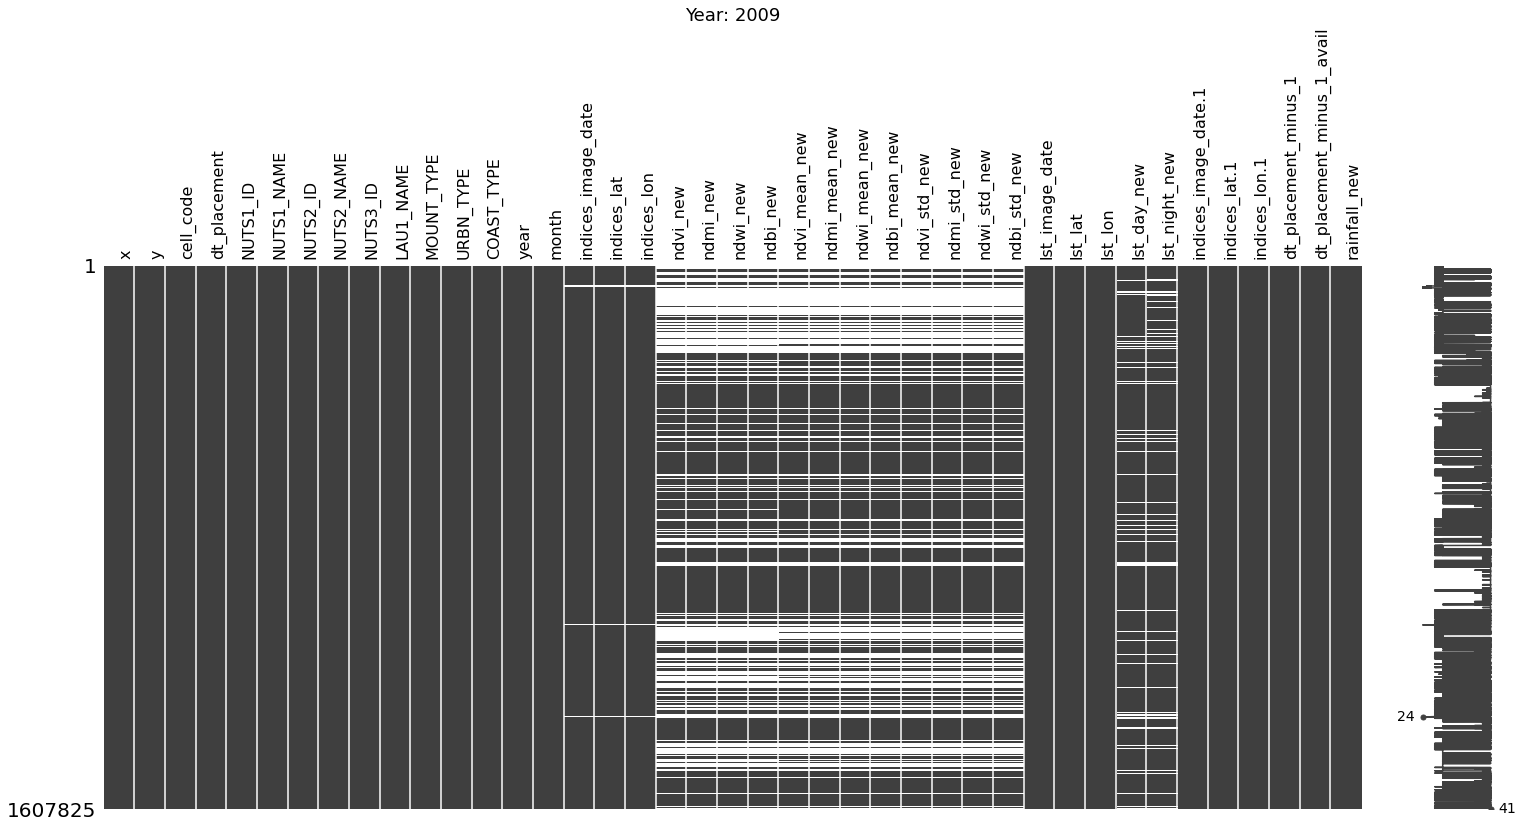

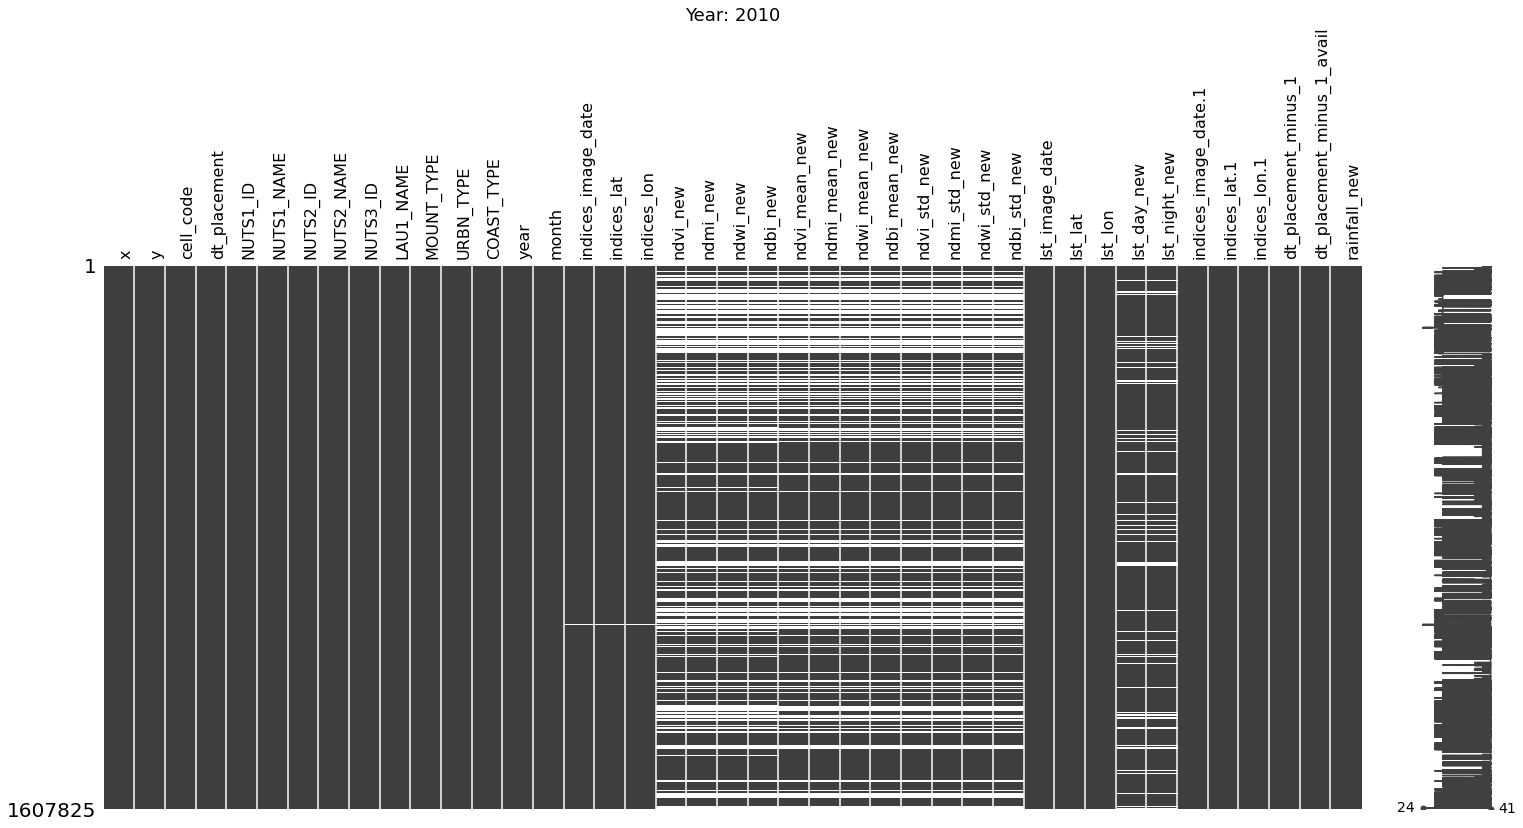

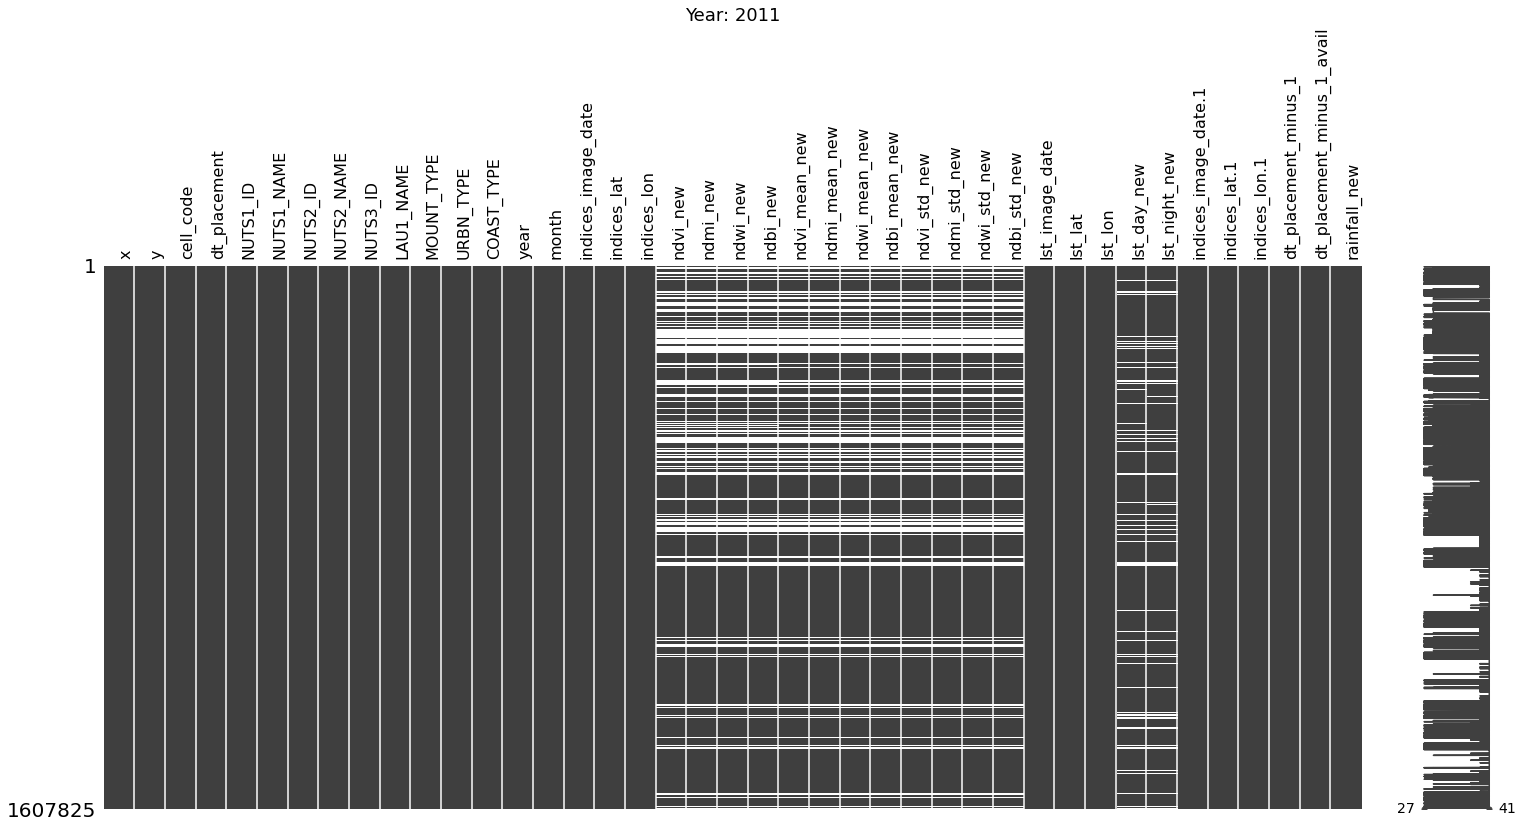

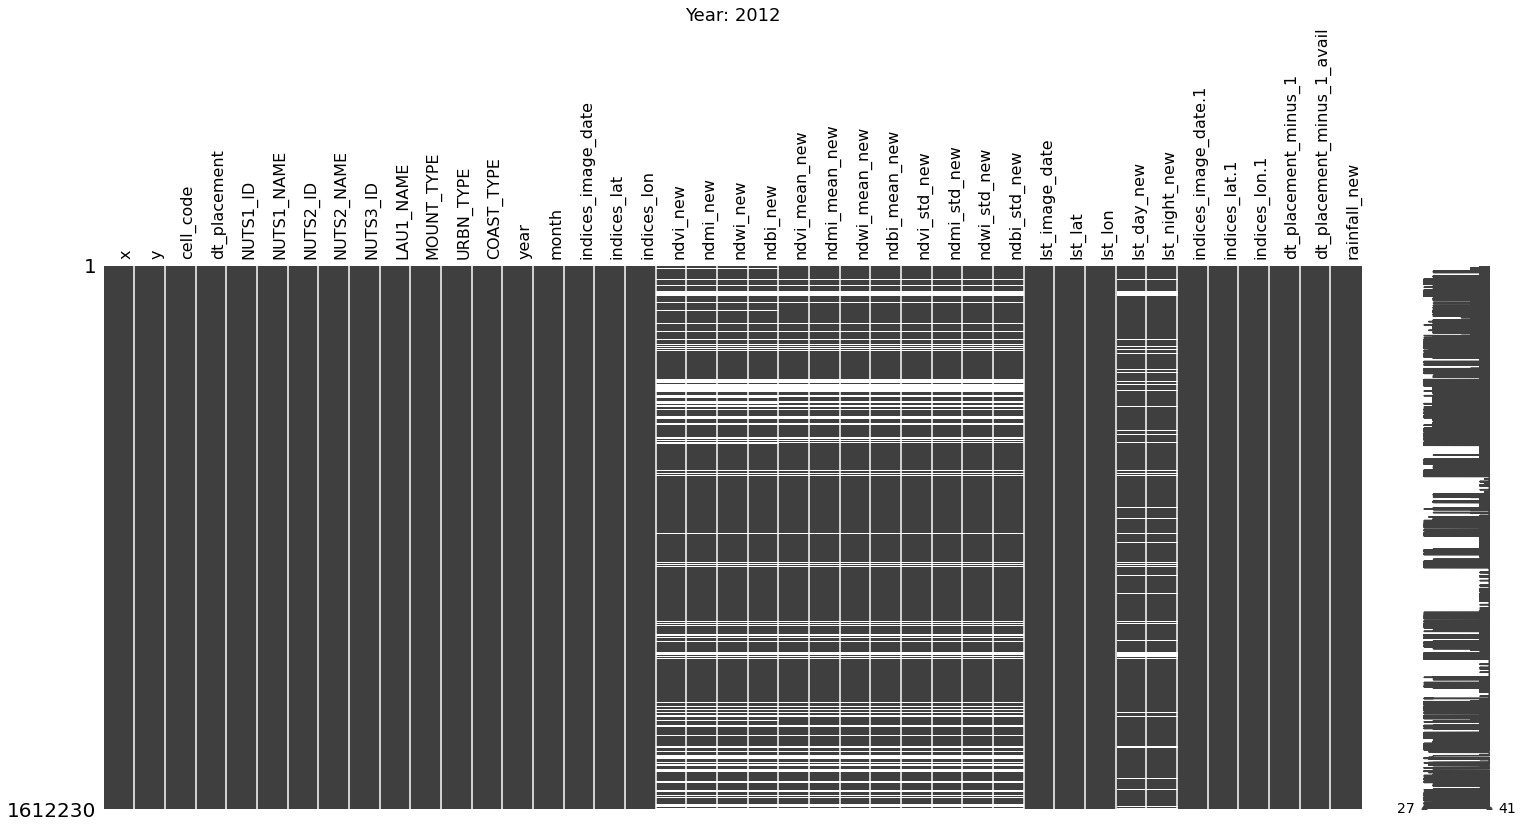

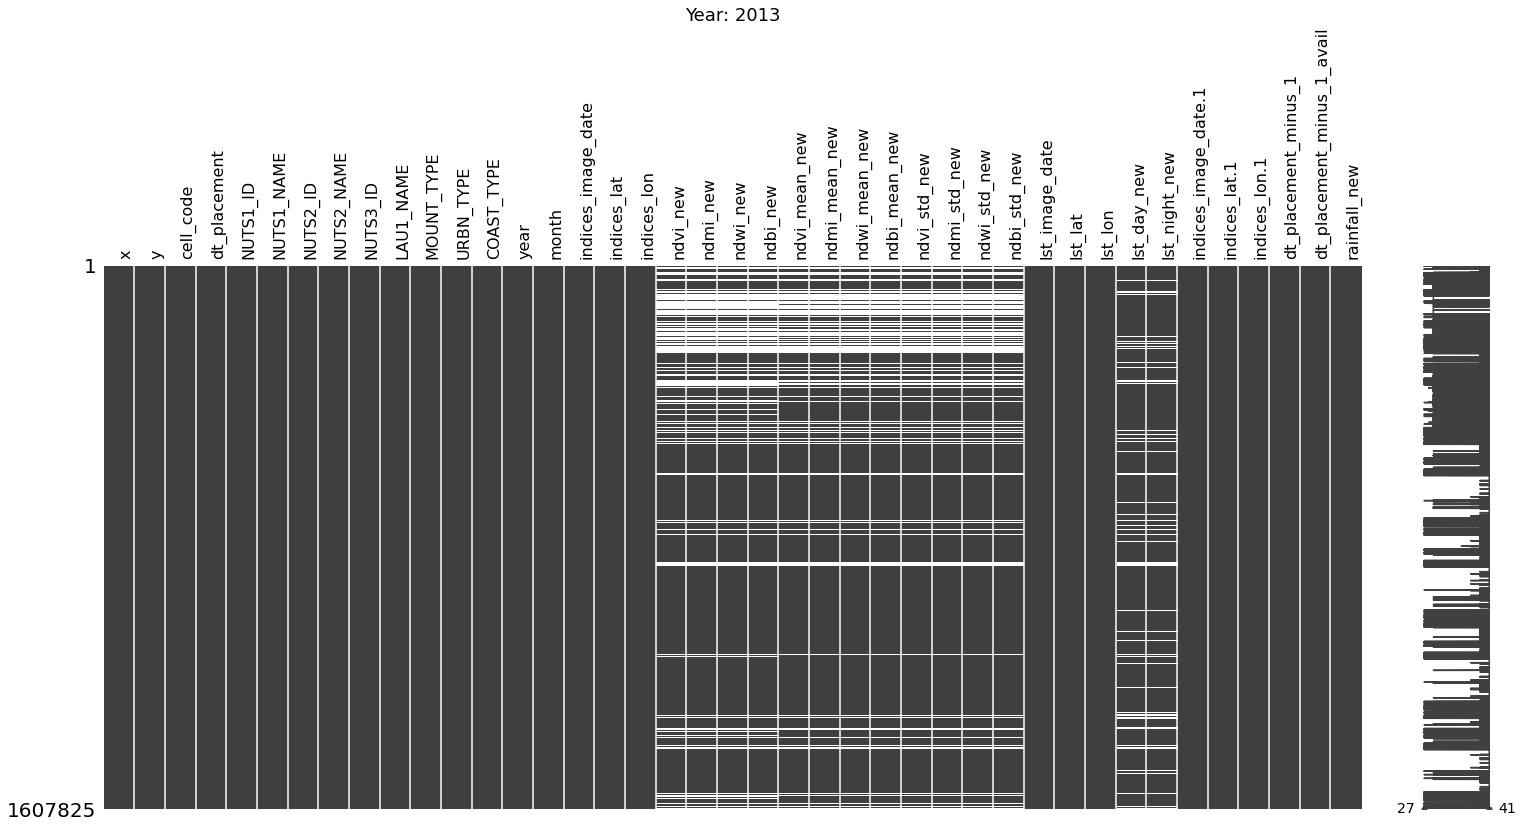

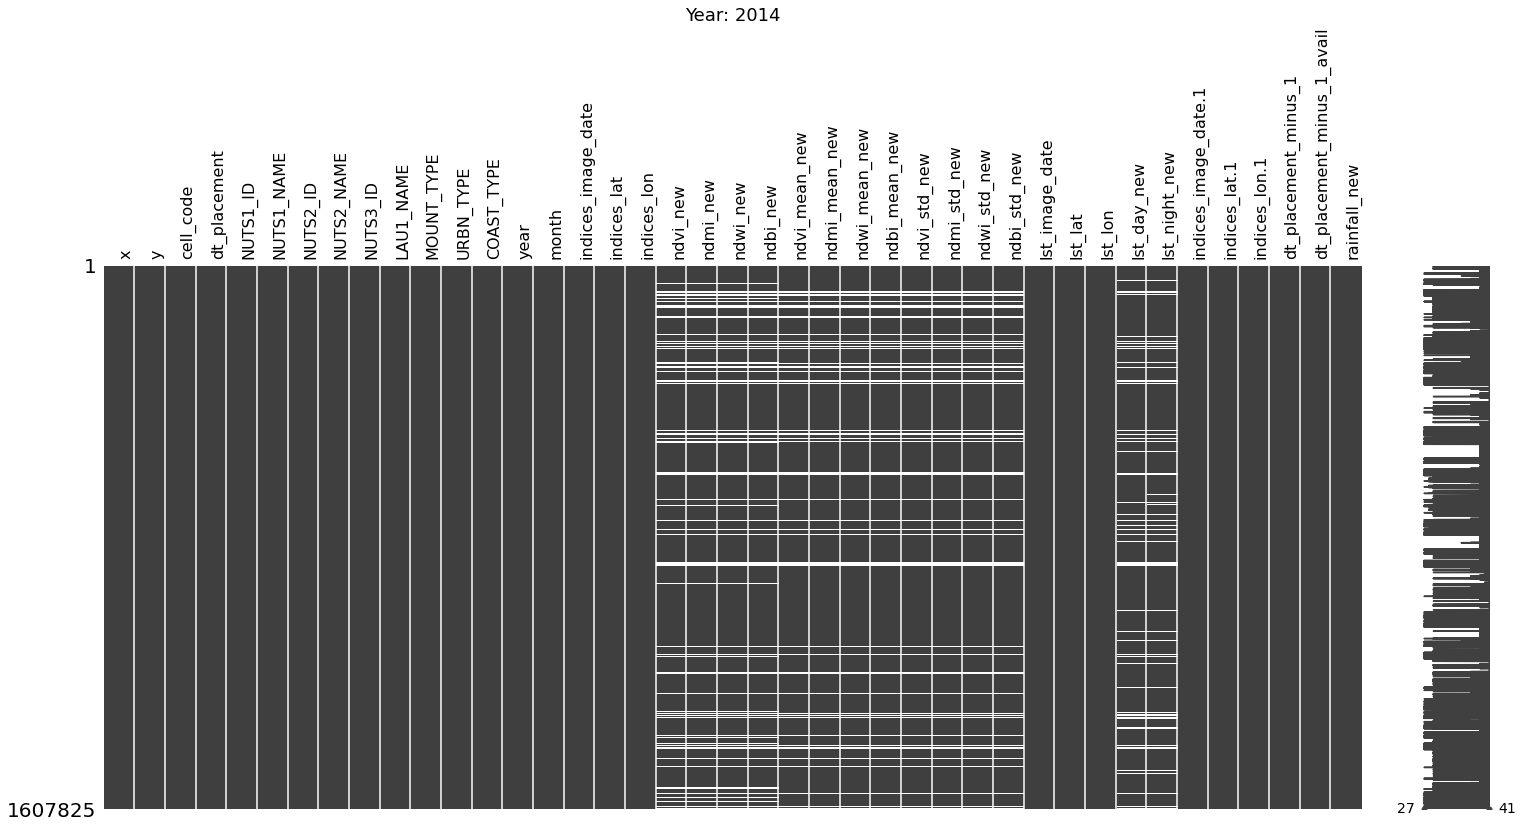

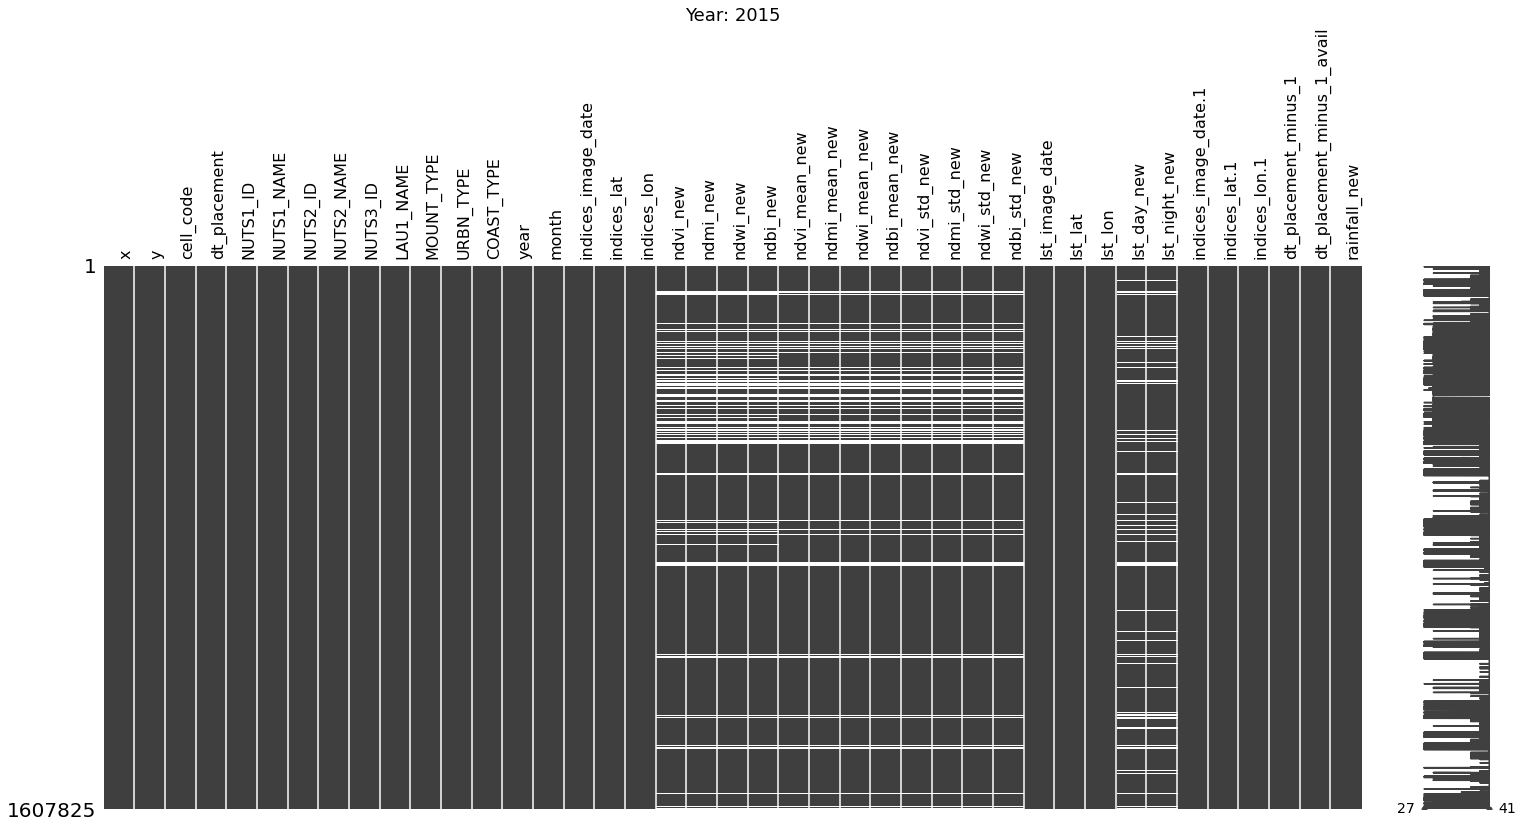

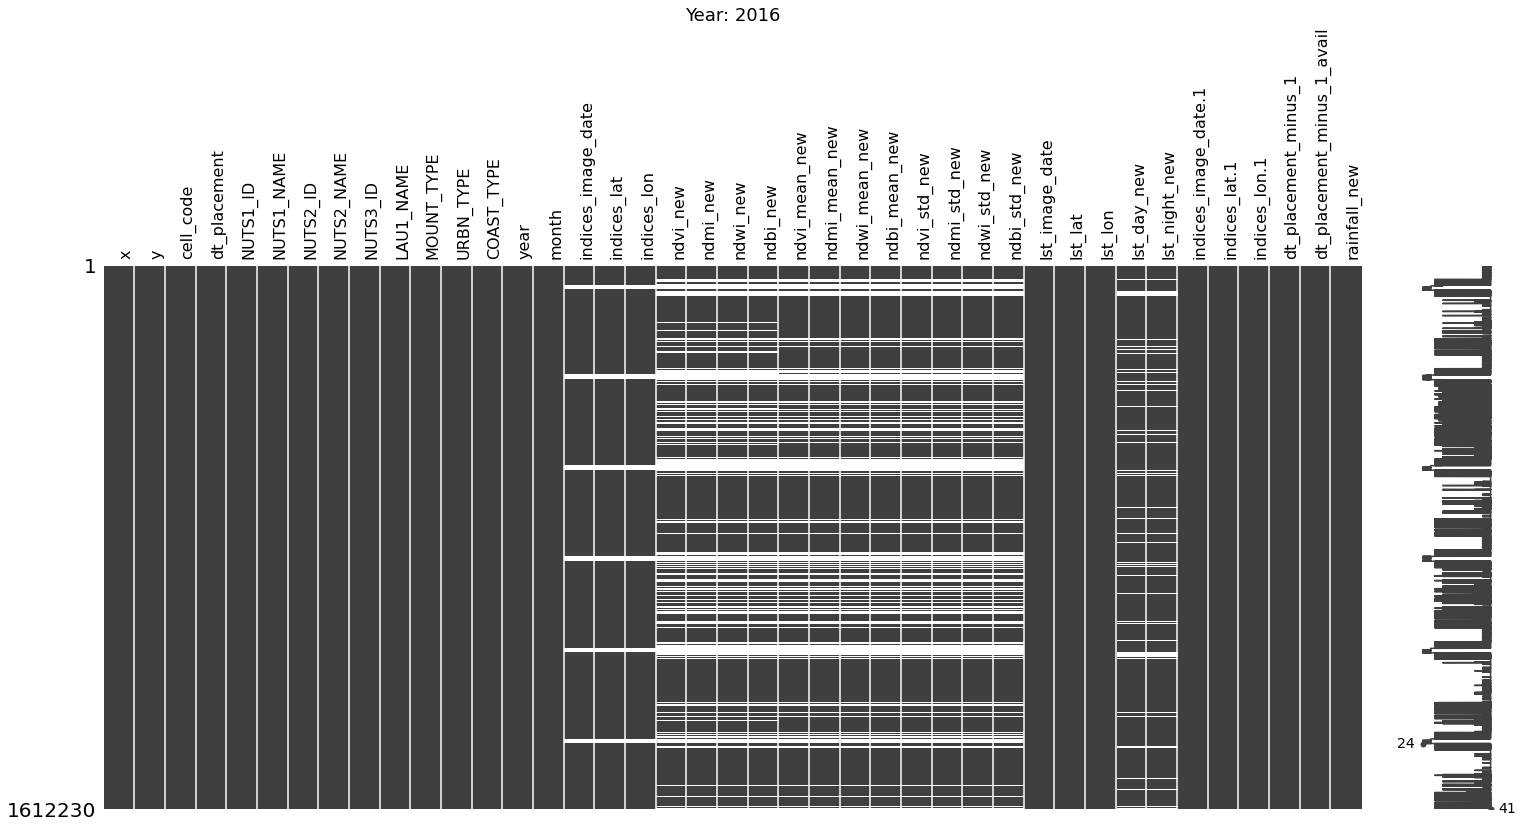

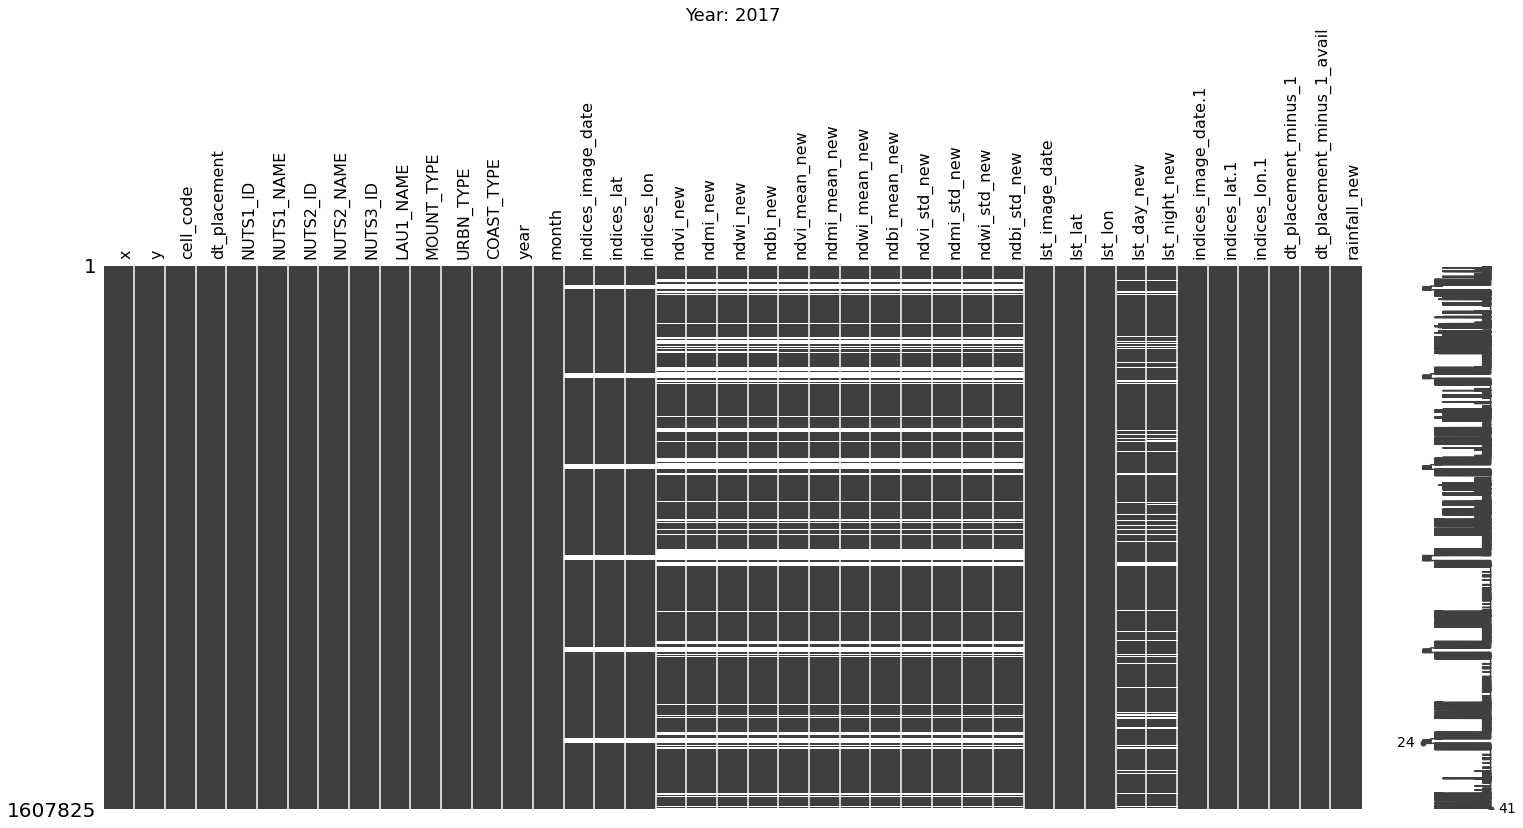

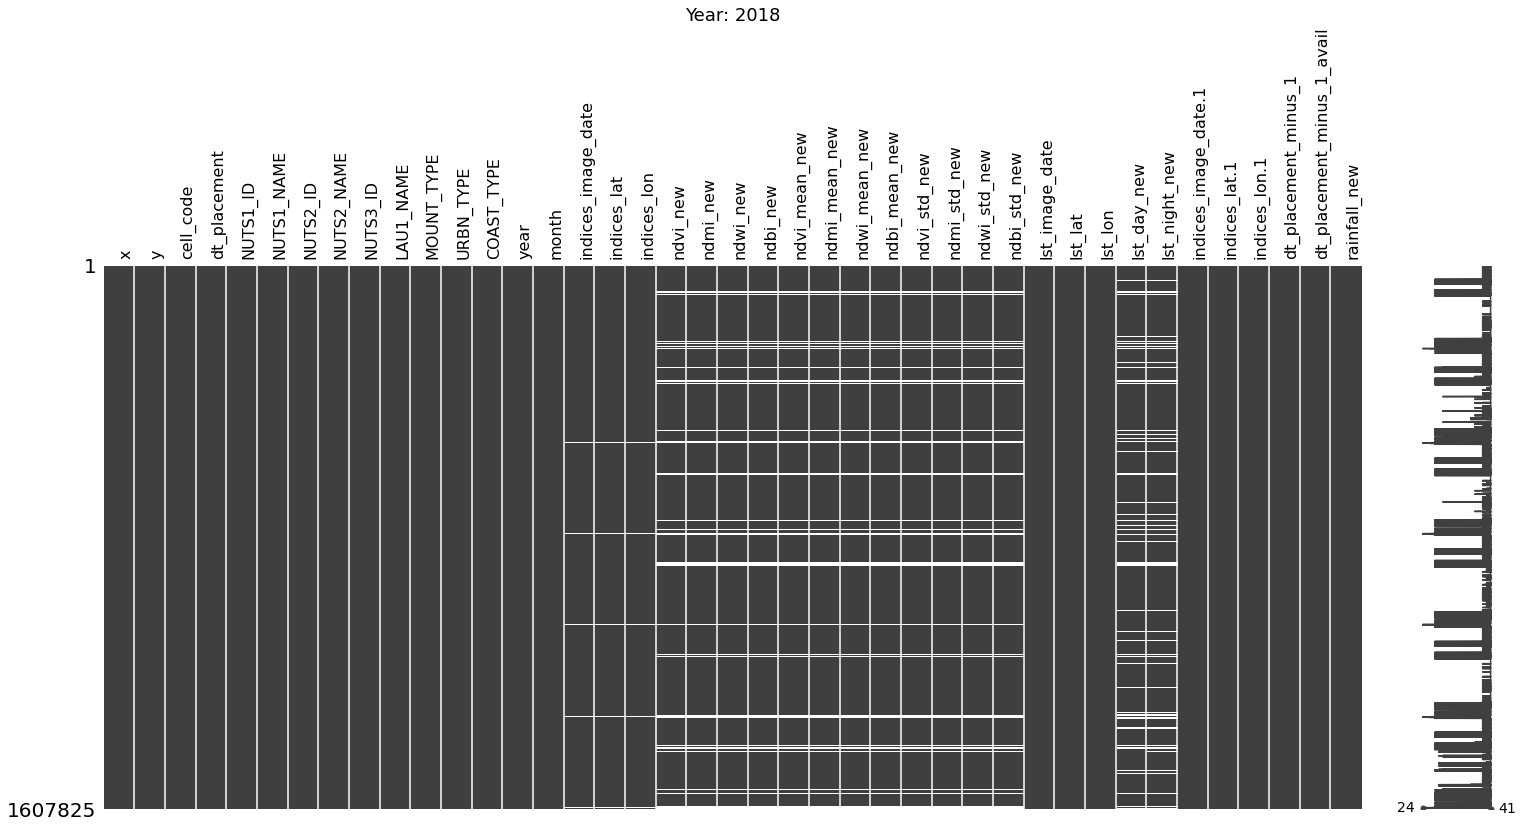

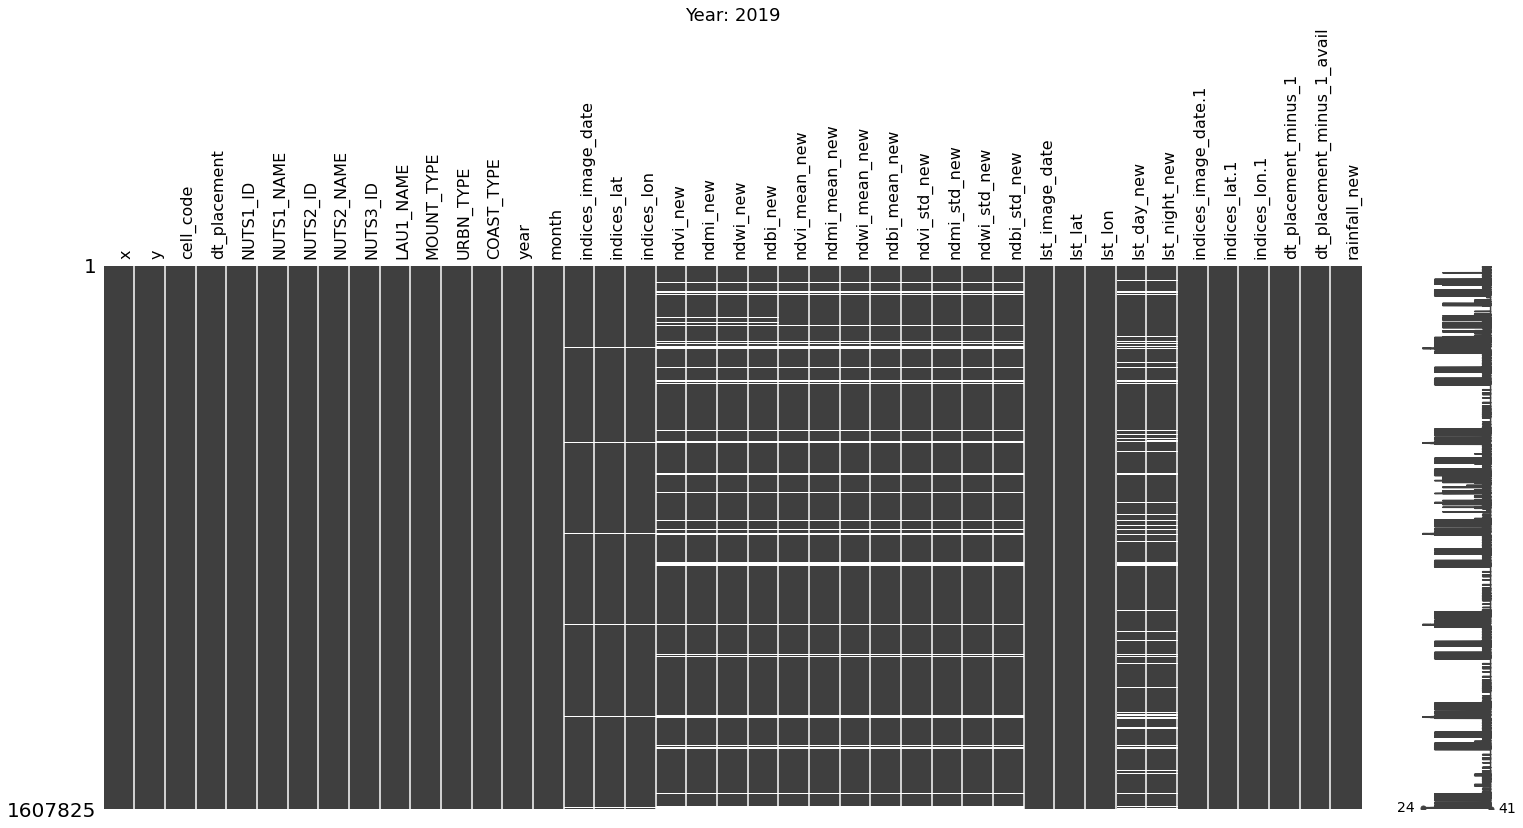

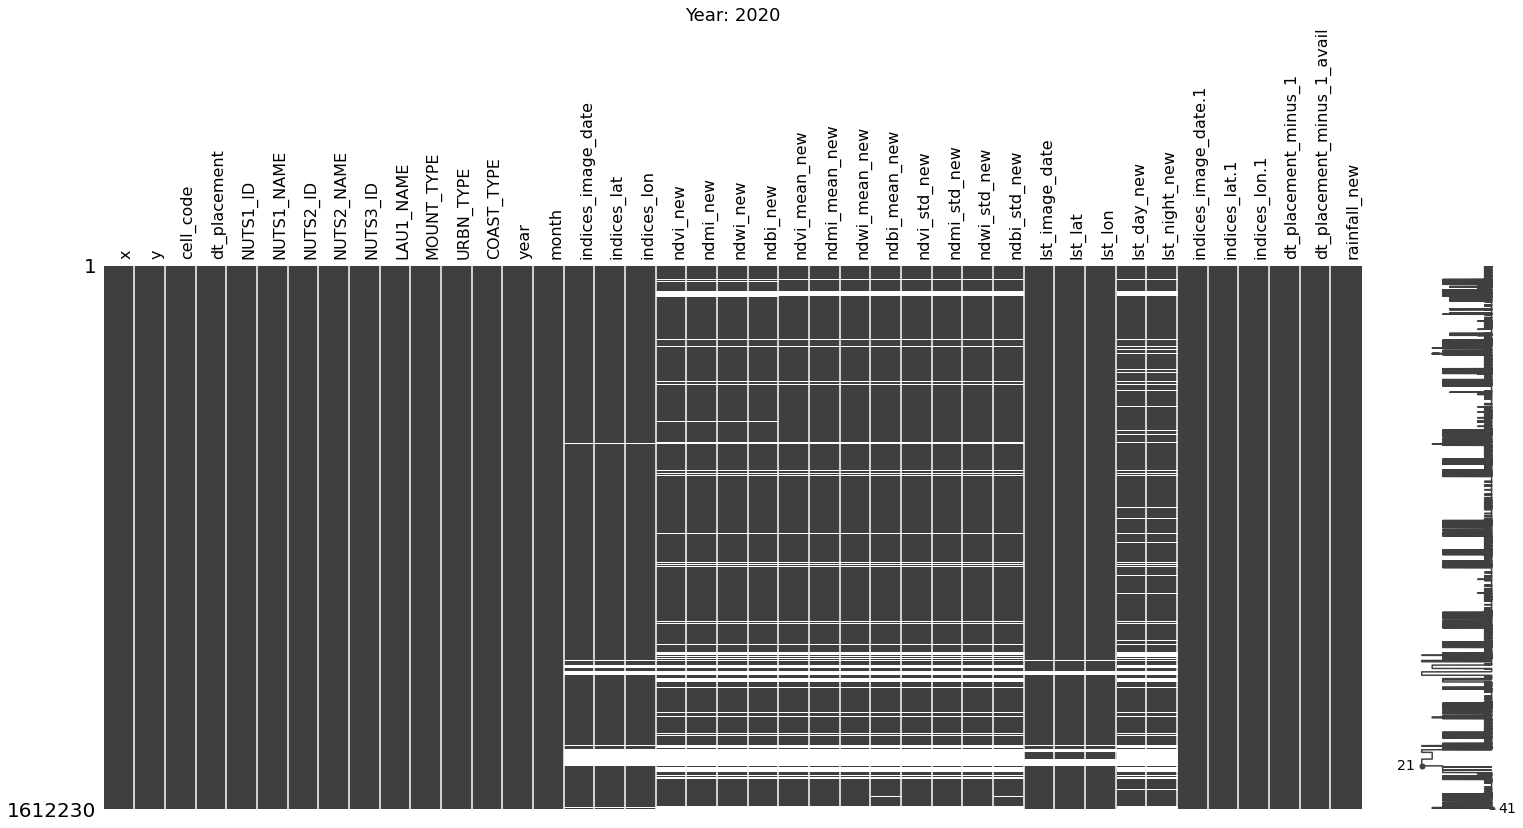

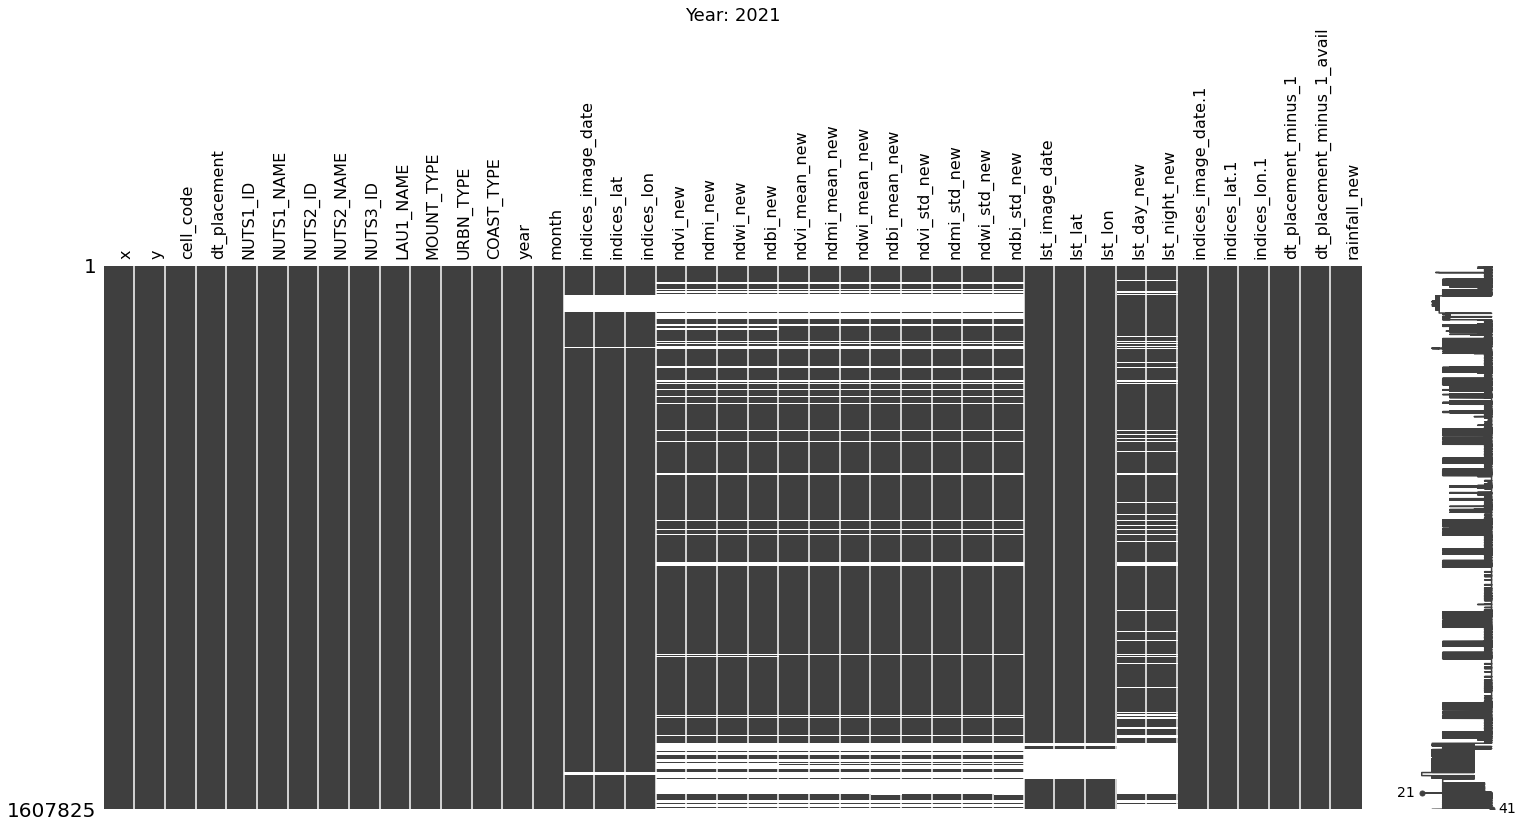

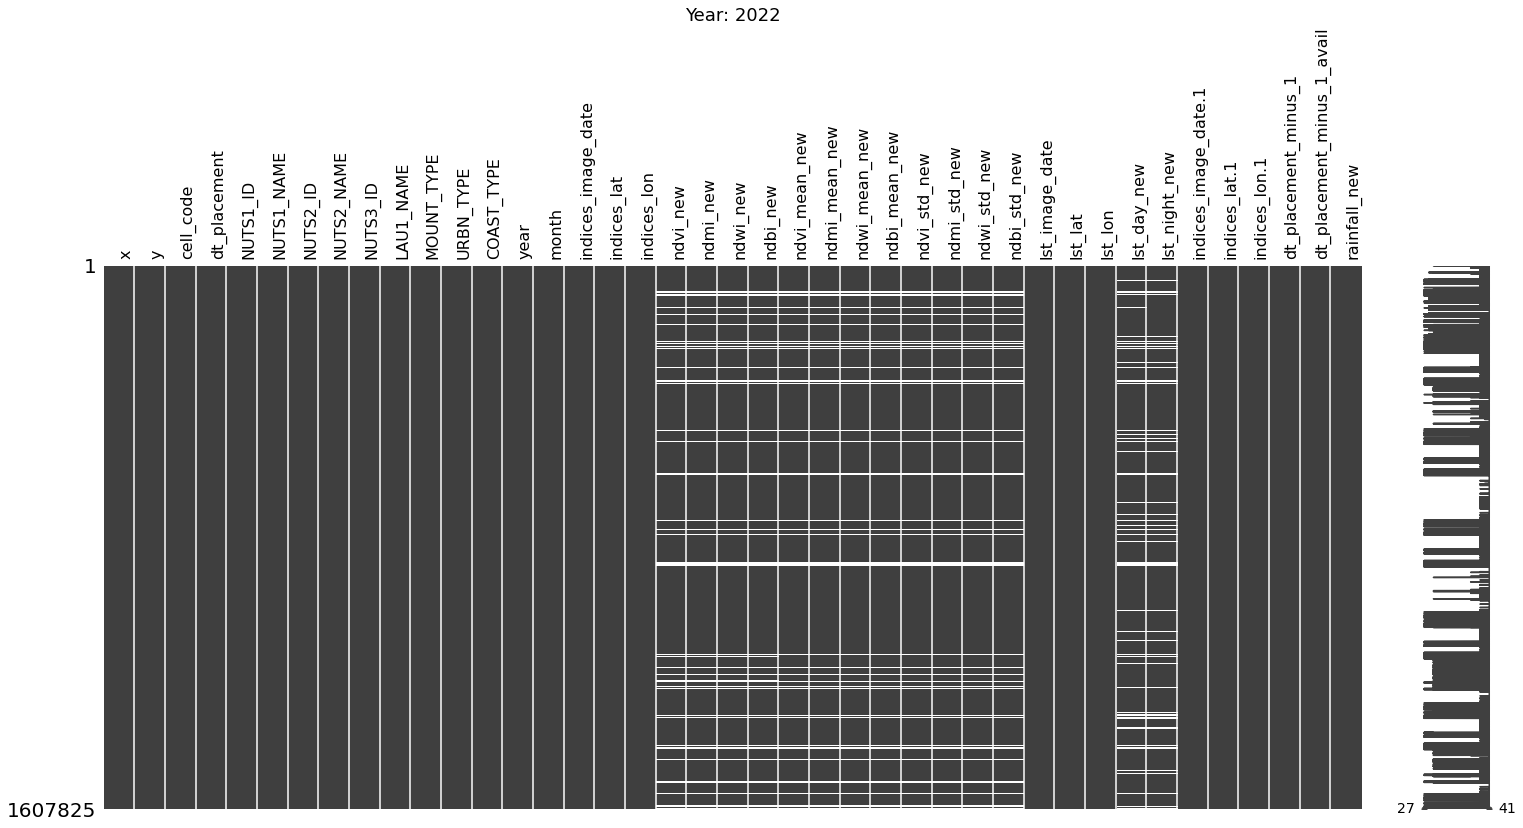

In [5]:
for data in data_per_year:
    msno.matrix(data, label_rotation=90)
    ax = plt.gca()
    ax.set_title(f"Year: {data.year.iloc[0]}", fontsize=18)

In [4]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
0,indices_image_date,1.5646
1,indices_lat,1.5646
2,indices_lon,1.5646
3,ndvi_new,18.6154
4,ndmi_new,18.6154
5,ndwi_new,18.6154
6,ndbi_new,18.6154
7,ndvi_mean_new,17.6306
8,ndmi_mean_new,17.6306
9,ndwi_mean_new,17.6306


In [5]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)
df = df.rename(columns=lambda x: re.sub('_new', '', x))
df['dt_placement']= pd.to_datetime(df['dt_placement'])
df['indices_image_date']= pd.to_datetime(df['indices_image_date'])
df['lst_image_date']= pd.to_datetime(df['lst_image_date'])
df['rainfall_image_date']= pd.to_datetime(df['rainfall_image_date'])

In [6]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
0,indices_image_date,1.5646
1,ndvi,18.6154
2,ndmi,18.6154
3,ndwi,18.6154
4,ndbi,18.6154
5,ndvi_mean,17.6306
6,ndmi_mean,17.6306
7,ndwi_mean,17.6306
8,ndbi_mean,17.6341
9,ndvi_std,17.6306


In [16]:
df2 = df.copy()

In [17]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

In [18]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
0,indices_image_date,1.5646
1,ndvi,27.1718
2,ndmi,27.1718
3,ndwi,27.1718
4,ndbi,27.1718
5,ndvi_mean,26.4080
6,ndmi_mean,26.4080
7,ndwi_mean,26.4080
8,ndbi_mean,26.4115
9,ndvi_std,26.4080


In [19]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [20]:
df2.reset_index(drop=True, inplace=True)

In [21]:
df2

,x,y,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,23.722470,38.078795,OU372,2009-01-01,EL3,αττικη,EL30,αττικη,EL305,αχαρνων,2.0,1.0,1.0,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14112.0,13780.0,0.000000
1,23.722470,38.078795,OU372,2009-01-02,EL3,αττικη,EL30,αττικη,EL305,αχαρνων,2.0,1.0,1.0,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14112.0,13780.0,2.866936
2,23.722470,38.078795,OU372,2009-01-03,EL3,αττικη,EL30,αττικη,EL305,αχαρνων,2.0,1.0,1.0,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14112.0,13780.0,13.926683
3,23.722470,38.078795,OU372,2009-01-04,EL3,αττικη,EL30,αττικη,EL305,αχαρνων,2.0,1.0,1.0,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14112.0,13780.0,2.439608
4,23.722470,38.078795,OU372,2009-01-05,EL3,αττικη,EL30,αττικη,EL305,αχαρνων,2.0,1.0,1.0,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14112.0,13780.0,10.252046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22522760,22.205622,38.561047,MR240,2022-12-27,EL6,κεντρικη ελλαδα,EL64,στερεα ελλαδα,EL645,δωριδος,3.0,3.0,1.0,2022,12,0.286783,0.262643,-0.072022,-0.262643,0.355929,0.180265,-0.212274,-0.180265,0.05997,0.098978,0.11779,0.098978,14211.0,13959.0,0.000000
22522761,22.205622,38.561047,MR240,2022-12-28,EL6,κεντρικη ελλαδα,EL64,στερεα ελλαδα,EL645,δωριδος,3.0,3.0,1.0,2022,12,0.286783,0.262643,-0.072022,-0.262643,0.355929,0.180265,-0.212274,-0.180265,0.05997,0.098978,0.11779,0.098978,14139.0,13975.0,0.000000
22522762,22.205622,38.561047,MR240,2022-12-29,EL6,κεντρικη ελλαδα,EL64,στερεα ελλαδα,EL645,δωριδος,3.0,3.0,1.0,2022,12,0.286783,0.262643,-0.072022,-0.262643,0.355929,0.180265,-0.212274,-0.180265,0.05997,0.098978,0.11779,0.098978,14083.0,13833.0,0.000000
22522763,22.205622,38.561047,MR240,2022-12-30,EL6,κεντρικη ελλαδα,EL64,στερεα ελλαδα,EL645,δωριδος,3.0,3.0,1.0,2022,12,0.286783,0.262643,-0.072022,-0.262643,0.355929,0.180265,-0.212274,-0.180265,0.05997,0.098978,0.11779,0.098978,13802.0,13859.0,0.000000


In [22]:
df2.to_csv(f'GR_Timeline_2009-2022_filled_2.csv', encoding='utf-8')